In [1]:
from Bio import SeqIO
from collections import defaultdict
import csv
import gzip
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyliftover
import re
import scipy
from tqdm.auto import tqdm
import warnings

### Load Probe Sites (liftover to hg38)

In [2]:
probe_sites = pd.read_csv(
    "../data/methylation/GPL21145_MethylationEPIC_15073387_v-1-0.csv.gz",
    compression="infer",
    skiprows=7
)

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58856/792207803.py:1: DtypeWarning: Columns (0: IlmnID, 1: AddressA_ID, 2: AddressB_ID, 3: AlleleB_ProbeSeq, 4: Infinium_Design_Type, 5: Next_Base, 6: Color_Channel, 7: Forward_Sequence, 8: CHR, 9: SourceSeq, 10: UCSC_RefGene_Name, 11: UCSC_RefGene_Accession, 12: UCSC_RefGene_Group, 13: UCSC_CpG_Islands_Name, 14: Relation_to_UCSC_CpG_Island, 15: Phantom4_Enhancers, 16: Phantom5_Enhancers, 17: DMR, 18: 450k_Enhancer, 19: Regulatory_Feature_Name, 20: Regulatory_Feature_Group, 21: GencodeBasicV12_NAME, 22: GencodeBasicV12_Accession, 23: GencodeBasicV12_Group, 24: GencodeCompV12_NAME, 25: GencodeCompV12_Accession, 26: GencodeCompV12_Group, 27: DNase_Hypersensitivity_NAME, 28: OpenChromatin_NAME, 29: TFBS_NAME, 30: Methyl27_Loci, 31: Methyl450_Loci, 32: Chromosome_36, 33: SNP_ID, 34: SNP_DISTANCE, 35: SNP_MinorAlleleFrequency, 36: Random_Loci) have mixed types. Specify dtype option on import or set low_memory=False.
  probe_sites = 

In [3]:
# Liftover to hg38, since our annotations are hg38
lo = pyliftover.LiftOver('hg19', 'hg38')
def liftover_hg19_hg38(chrom, pos):
    result = lo.convert_coordinate(f"chr{chrom}", pos)
    if result is None or len(result) == 0:
        return [None, None]
    if len(result) > 1:
        return ["Multiple", "Multiple"]

    new_chrom, new_pos, strand, score = result[0]
    return new_chrom, new_pos

probe_sites[["CHR_hg38", "MAPINFO_hg38"]] = probe_sites.apply(
    lambda x: liftover_hg19_hg38(x["CHR"], x["MAPINFO"]), axis=1, result_type="expand",
)

In [4]:
print("Total", len(probe_sites))
print("Failed to liftover", probe_sites["MAPINFO_hg38"].isna().sum())
print("Mapped to multiple coordinates", (probe_sites["MAPINFO_hg38"] == "Multiple").sum())

Total 868565
Failed to liftover 797
Mapped to multiple coordinates 0


In [5]:
# Discard probes that failed to liftover
probe_sites = probe_sites.loc[~probe_sites["MAPINFO_hg38"].isna()]
probe_sites["CHR_hg38"] = probe_sites["CHR_hg38"].astype(str)
probe_sites["MAPINFO_hg38"] = probe_sites["MAPINFO_hg38"].astype(int)

### Check Probe Locations on Reference Assembly

In [ ]:
fasta_file = "../dependencies/GRCh38.p14.genome.fa.gz"
opener = gzip.open if str(fasta_file).endswith(".gz") else open
with opener(fasta_file, "rt") as f:
    fasta_index = SeqIO.to_dict(SeqIO.parse(f, "fasta"))

In [7]:
def get_sequence(chrom, start, end, strand):
    seq = fasta_index[chrom].seq[start-1:end]
    if strand == '-':
        seq = seq.reverse_complement()
    return str(seq)

In [8]:
cpg_lookup = defaultdict(set)
mismatch_cpg_ref = defaultdict(set)
probe_id_lookup = defaultdict(str)

keep_chr = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

for chrom, pos, pid in tqdm(zip(probe_sites["CHR_hg38"], probe_sites["MAPINFO_hg38"], probe_sites["IlmnID"])):
    if chrom not in keep_chr:
        continue

    # Check if REF sequence is still CpG (original data is from hg19)
    if get_sequence(chrom, pos, pos+1, "+") == "CG":
        cpg_lookup[chrom].add(pos)
    else:
        mismatch_cpg_ref[chrom].add(pos)

    probe_id_lookup[(chrom, pos)] = pid

0it [00:00, ?it/s]

In [9]:
for chrom in sorted(cpg_lookup.keys()):
    total = len(cpg_lookup[chrom]) + len(mismatch_cpg_ref[chrom])
    pass_pct = 100 * len(cpg_lookup[chrom]) / total
    print(
        chrom, 
        "Total CpG sites:", len(cpg_lookup[chrom]),
    )

chr1 Total CpG sites: 80990
chr10 Total CpG sites: 41618
chr11 Total CpG sites: 48876
chr12 Total CpG sites: 44581
chr13 Total CpG sites: 20987
chr14 Total CpG sites: 29503
chr15 Total CpG sites: 28387
chr16 Total CpG sites: 37973
chr17 Total CpG sites: 44404
chr18 Total CpG sites: 14894
chr19 Total CpG sites: 38581
chr2 Total CpG sites: 64633
chr20 Total CpG sites: 22943
chr21 Total CpG sites: 10214
chr22 Total CpG sites: 18269
chr3 Total CpG sites: 48804
chr4 Total CpG sites: 36654
chr5 Total CpG sites: 44674
chr6 Total CpG sites: 54348
chr7 Total CpG sites: 47475
chr8 Total CpG sites: 38367
chr9 Total CpG sites: 26039
chrX Total CpG sites: 18992
chrY Total CpG sites: 561


### Map Probe Locations to Annotated Exons

In [10]:
def load_gtf(gtf_file):
    return pd.read_csv(
        gtf_file,
        sep="\t",
        comment="#",
        header=None,
        dtype=str,
        quoting=csv.QUOTE_NONE,
        names=[
            "seqid", "source", "type", "start", "end", "score",
            "strand", "phase", "attributes"
        ],
    )

def extract_attr(attr_str, key):
    # GTF format: key "value";
    match = re.search(rf'{key} "([^"]+)"', attr_str)
    return match.group(1) if match else None

def parse_attributes(df):
    for k in ["gene_id", "gene_name", "gene_type", "transcript_id", "transcript_type"]:
        df[k] = df["attributes"].apply(lambda x: extract_attr(x, k))
    return df

In [11]:
gtf = load_gtf("../dependencies/gencode.v49.primary_assembly.basic.annotation.gtf.gz")

gtf["start"] = gtf["start"].astype(int)
gtf["end"] = gtf["end"].astype(int)
# Keep only chromosomal genes/transcripts/exons
gtf = gtf.loc[gtf["seqid"].isin(keep_chr)]
gtf = gtf[gtf["type"].isin(["gene", "transcript", "exon"])]

gtf = parse_attributes(gtf)

In [12]:
results = []

for idx, row in tqdm(gtf.iterrows(), total=len(gtf)):
    chrom = row["seqid"]
    start, end = row["start"], row["end"]
    strand = row["strand"]
    feature_type = row["type"]

    assert chrom in fasta_index
    
    seq = get_sequence(chrom, start, end, strand)

    # Find all CpG positions
    cpg_positions = [start + m.start() for m in re.finditer("CG", seq)]
    n_cpg_total = len(cpg_positions)

    # Check how many are present in methylation dataframe
    present_positions = [pos for pos in cpg_positions if pos in cpg_lookup[chrom]]
    probe_ids = [probe_id_lookup[(chrom, pos)] for pos in present_positions]
    n_cpg_present = len(present_positions)
    n_cpg_missing = n_cpg_total - n_cpg_present

    results.append({
        "feature_type": feature_type,
        "chrom": chrom,
        "start": start,
        "end": end,
        "strand": strand,
        "gene_id": row.get("gene_id"),
        "gene_name": row.get("gene_name"),
        "transcript_id": row.get("transcript_id"),
        "transcript_type": row.get("transcript_type"),
        "gene_type": row.get("gene_type"),
        "n_cpg_total": n_cpg_total,
        "n_cpg_present": n_cpg_present,
        "n_cpg_missing": n_cpg_missing,
        "present_positions": present_positions,
        "present_probe_ids": probe_ids,
    })

results_df = pd.DataFrame(results)

  0%|          | 0/2884041 [00:00<?, ?it/s]

In [13]:
protein_coding_exons = results_df[
    (
        (results_df["feature_type"] == "exon") &
        (results_df["gene_type"] == "protein_coding") &
        (results_df["transcript_type"] == "protein_coding")
    )
].drop_duplicates(["chrom", "start", "end"])

### Load Probe Measurements

In [14]:
MV411_measurements = pd.read_csv(
    "../data/methylation/GSE135205_DNMT1_MV411_Epic_methylation_betas.txt.gz",
    sep="\t",
    compression="gzip",
).reset_index()

MV411_measurements = pd.merge(
    probe_sites, MV411_measurements,
    left_on="IlmnID", right_on="index",
    how="inner",
    validate="1:1",
)

MV411_measurements = MV411_measurements.set_index("IlmnID")

In [15]:
# Calculate methylation depletion level (DMSO / GSK032A) for each time point
for i, day in enumerate([1, 2, 4, 6]):
    MV411_measurements[f"GSK032A.400nM.d{day}.depletion"] = \
        MV411_measurements[f"DMSO.0nM.d{day}"] / MV411_measurements[f"GSK032A.400nM.d{day}"]

In [16]:
# All probe value columns (exclude IlmnID)
probe_cols = ['DMSO.0nM.d1', 'GSK032A.400nM.d1',
       'DMSO.0nM.d2', 'GSK032A.400nM.d2', 'GSK862A.1000nM.d2',
       'GSK477A.10000nM.d2', 'DMSO.0nM.d4', 'GSK032A.3.2nM.d4',
       'GSK032A.16nM.d4', 'GSK032A.80nM.d4', 'GSK032A.400nM.d4',
       'GSK032A.2000nM.d4', 'GSK032A.10000nM.d4', 'GSK862A.1000nM.d4',
       'GSK477A.10000nM.d4', 'DMSO.0nM.d6', 'GSK032A.400nM.d6',
       'GSK032A.400nM.d1.depletion', 'GSK032A.400nM.d2.depletion',
       'GSK032A.400nM.d4.depletion', 'GSK032A.400nM.d6.depletion']

In [17]:
def collect_probe_values(probe_ids):
    matched = MV411_measurements.loc[MV411_measurements.index.intersection(probe_ids)]
    # Build dictionary of column: list of values
    return {
        f'probe_{col}_list': matched[col].tolist()
        for col in probe_cols
    }

probe_data = protein_coding_exons['present_probe_ids'].apply(collect_probe_values)
probe_df = pd.DataFrame(probe_data.tolist())
protein_coding_exons_with_measurements = pd.concat([protein_coding_exons.reset_index(drop=True), probe_df], axis=1)

In [18]:
# Calculate exon-wide aggregate depletion levels
for i, day in enumerate([1, 2, 4, 6]):
    protein_coding_exons_with_measurements[f"probe_GSK032A.400nM.d{day}.depletion_exon_mean"] = \
    protein_coding_exons_with_measurements.apply(
        lambda x: np.nansum(x[f"probe_DMSO.0nM.d{day}_list"]) / np.nansum(x[f"probe_GSK032A.400nM.d{day}_list"]),
        axis=1
    )
    protein_coding_exons_with_measurements[f"probe_GSK032A.400nM.d{day}.depletion_exon_std"] = \
    protein_coding_exons_with_measurements.apply(
        lambda x: np.nanstd(x[f"probe_GSK032A.400nM.d{day}.depletion_list"]),
        axis=1
    )

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58856/2613933536.py:5: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: np.nansum(x[f"probe_DMSO.0nM.d{day}_list"]) / np.nansum(x[f"probe_GSK032A.400nM.d{day}_list"]),
/Users/simonliu/.pyenv/versions/3.12.13/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58856/2613933536.py:5: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: np.nansum(x[f"probe_DMSO.0nM.d{day}_list"]) / np.nansum(x[f"probe_GSK032A.400nM.d{day}_list"]),
/Users/simonliu/.pyenv/versions/3.12.13/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_588

### Load rMATS differential exon skipping events

In [19]:
MV411_DMSO_400nM_GSK032_d4_n2_se = pd.read_csv(
    "../data/methylation/Pappalardi2019_MV411.0nM.DMSO.400nM.GSK032.d4.n2_rMATS_SE.MATS.JCEC.txt.gz",
    sep="\t",
)
MV411_DMSO_400nM_GSK032_d4_n2_se = MV411_DMSO_400nM_GSK032_d4_n2_se \
    .loc[MV411_DMSO_400nM_GSK032_d4_n2_se["chr"].isin(keep_chr)]

MV411_DMSO_400nM_GSK032_d4_n2_se["exonStart_1base"] = \
    MV411_DMSO_400nM_GSK032_d4_n2_se["exonStart_0base"] + 1

In [20]:
# Note that this is an inner join, so noncanonical junctions are excluded
# The validation is many:1 because the splicing events are unique by (upstream, exon, downstream) tuples
MV411_DMSO_400nM_GSK032_d4_n2_se_measurements = pd.merge(
    MV411_DMSO_400nM_GSK032_d4_n2_se,
    protein_coding_exons_with_measurements,
    left_on=["geneSymbol", "chr", "strand", "exonStart_1base", "exonEnd"],
    right_on=["gene_name", "chrom", "strand", "start", "end"],
    how="inner",
    validate="m:1",
)

MV411_DMSO_400nM_GSK032_d4_n2_se_measurements = \
    MV411_DMSO_400nM_GSK032_d4_n2_se_measurements.loc[~MV411_DMSO_400nM_GSK032_d4_n2_se_measurements["probe_GSK032A.400nM.d4.depletion_exon_mean"].isna()]

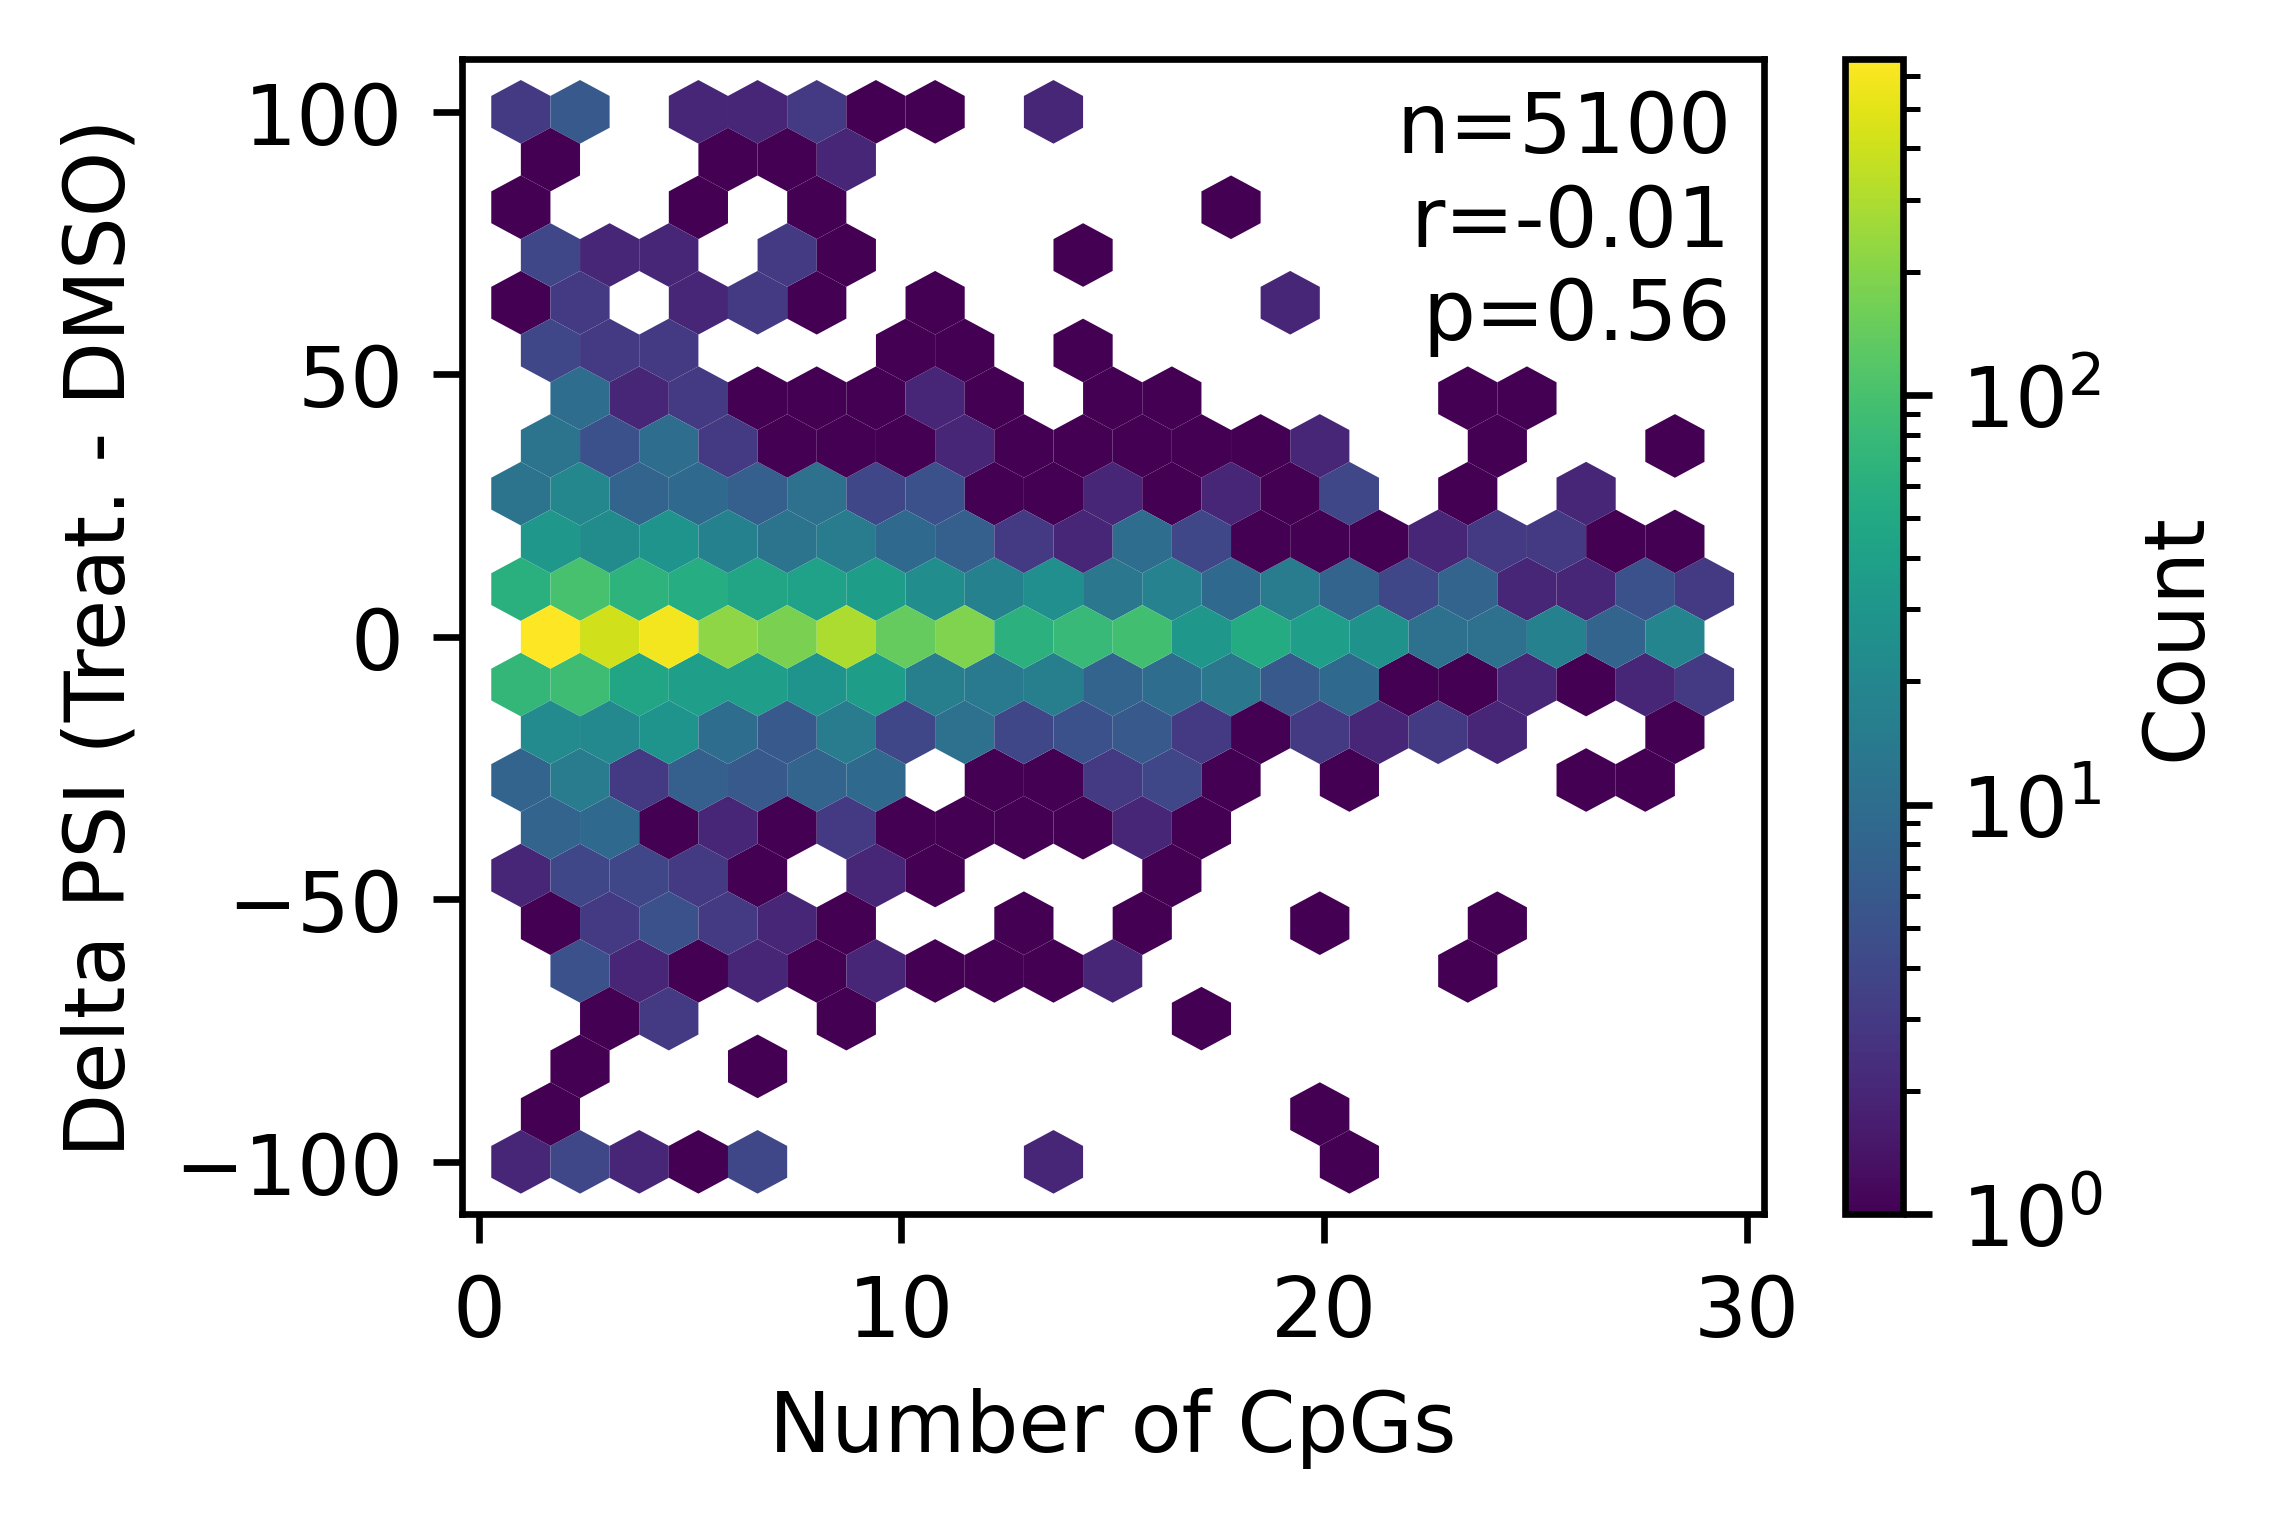

In [21]:
fig, ax = plt.subplots(1,1, figsize=(3.5,2.5), dpi=600)

df = MV411_DMSO_400nM_GSK032_d4_n2_se_measurements
x = df["n_cpg_total"]
y = -df["IncLevelDifference"] * 100

# Filter to exons with fewer than 30 CpG for visualization
mask = df["n_cpg_total"] < 30
x_mask = x.loc[mask]
y_mask = y.loc[mask]

# Hexbin plot
hb = ax.hexbin(
    x_mask,
    y_mask,
    bins="log",
    cmap="viridis",
    mincnt=1,
    gridsize=20,
    edgecolors='none',
    linewidths=0
)

# Note these are statistics without masking
r = scipy.stats.linregress(x, y)
ax.text(0.975, 0.975, f"n={len(x)}\nr={r.rvalue:.2f}\np={r.pvalue:.2f}", transform=ax.transAxes, va='top', ha='right')

fig.colorbar(hb, ax=ax, label="Count")

ax.set_xlabel("Number of CpGs")
ax.set_ylabel("Delta PSI (Treat. - DMSO)")
ax.set_title("")

fig.savefig("figures/MV411_400nM_GSK032_d4_n2_differential_se_cpg.svg", bbox_inches="tight")

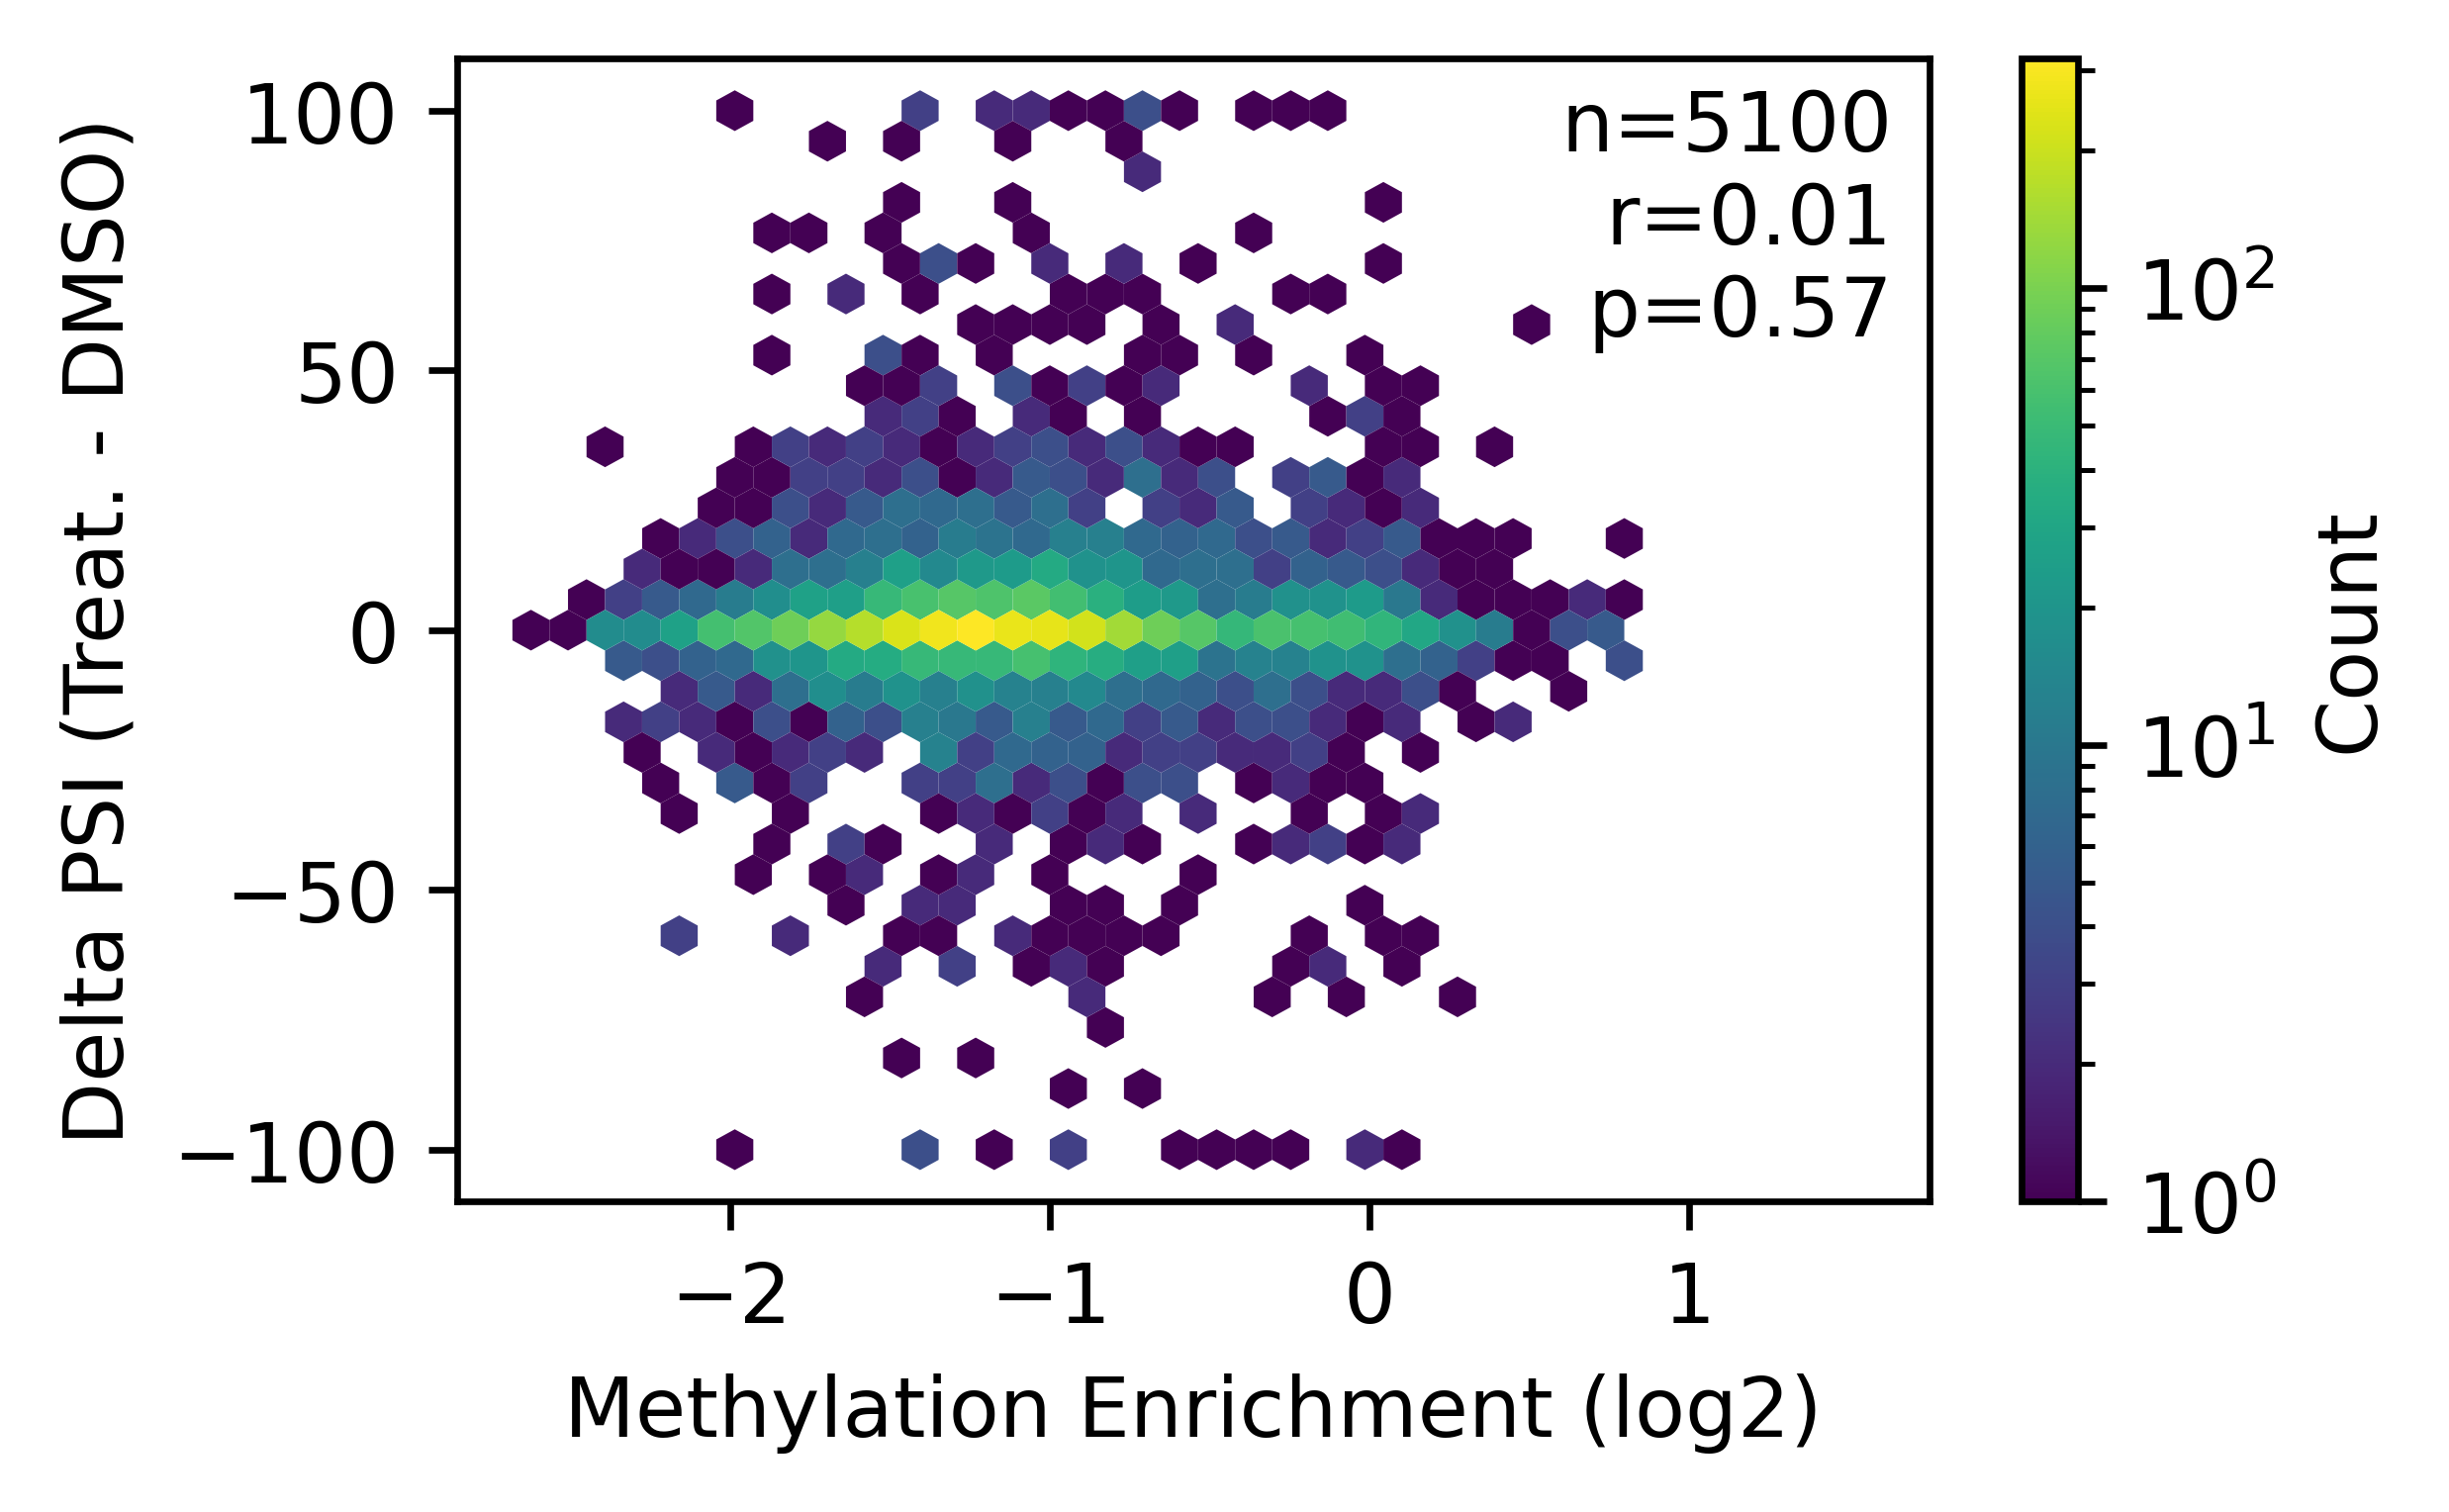

In [22]:
fig, ax = plt.subplots(1,1, figsize=(4,2.5), dpi=600)

df = MV411_DMSO_400nM_GSK032_d4_n2_se_measurements
x = -np.log2(df["probe_GSK032A.400nM.d4.depletion_exon_mean"])
y = -df["IncLevelDifference"] * 100

# Hexbin plot
hb = ax.hexbin(
    x,
    y,
    bins="log",
    cmap="viridis",
    mincnt=1,
    gridsize=30,
    edgecolors='none',
    linewidths=0
)

# Note these are statistics without masking
r = scipy.stats.linregress(x, y)
ax.text(0.975, 0.975, f"n={len(x)}\nr={r.rvalue:.2f}\np={r.pvalue:.2f}", transform=ax.transAxes, va='top', ha='right')

fig.colorbar(hb, ax=ax, label="Count")

ax.set_xlim(ax.get_xlim()[0], 1.75)
ax.set_xlabel("Methylation Enrichment (log2)")
ax.set_ylabel("Delta PSI (Treat. - DMSO)")
ax.set_title("")

fig.savefig("figures/MV411_400nM_GSK032_d4_n2_differential_se_methylation.svg", bbox_inches="tight")